<a href="https://colab.research.google.com/github/giahuy-ftel/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Mon Sep 14 08:20:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"

2.11.0+cu128


## 1. What are 3 areas in industry where computer vision is currently being used?

In [ ]:
# 1. Autonomous vehicles
# Computer vision is used to detect lanes, pedestrians, vehicles and traffic signs.

# 2. Manufacturing
# Computer vision is used for automatic visual inspection and defect detection.

# 3. Healthcare
# Computer vision is used to analyze medical images such as X-rays, CT scans and MRI images.

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

In [ ]:
# Overfitting happens when a model learns the training data too closely,
# including noise and specific patterns, so it performs well on training data
# but poorly on new/unseen data.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

In [ ]:
# 1. Add more training data
# More diverse data makes it harder for the model to memorize specific samples.

# 2. Train for fewer epochs / early stopping
# Stop training when validation performance stops improving.

# 3. Regularization
# Add a penalty to large weights so the model doesn't become overly complex.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
import torchvision
from torchvision import datasets, transforms

## 6. Visualize at least 5 different samples of the MNIST training dataset.

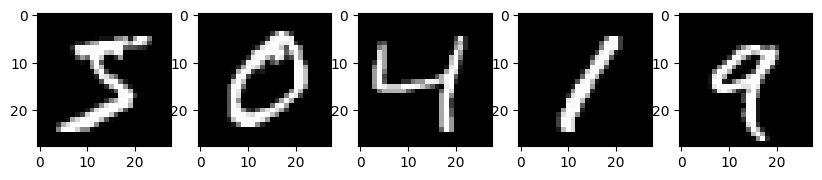

In [6]:
# Get data
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=None
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=None
)

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 10))
for i in range(5):
  img, label = train_data[i]
  img = img.squeeze()
  plt.subplot(1, 5, i+1)
  plt.imshow(img, cmap="gray")

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [7]:
from torch.utils.data import dataloader
BATCH_SIZE = 32
train_dataloader = dataloader.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = dataloader.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [9]:
class TinyVGG(torch.nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
        torch.nn.ReLU(),
        torch.nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.conv_block_2 = torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        torch.nn.ReLU(),
        torch.nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = torch.nn.Sequential(
      torch.nn.Flatten(),
      torch.nn.Linear(
          in_features=hidden_units * 7 * 7,
          out_features=output_shape
      )
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x


model = TinyVGG(input_shape=1, hidden_units=10, output_shape=10)
model

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [11]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()

    train_loss = 0
    train_acc = 0

    for batch, (X, y) in enumerate(dataloader):

        # 1. Move batch to device
        X = X.to(device)
        y = y.to(device)

        # 2. Forward pass
        y_logits = model(X)

        # 3. Calculate loss
        loss = loss_fn(y_logits, y)
        train_loss += loss.item()

        # 4. Accuracy
        y_pred = torch.argmax(y_logits, dim=1)
        train_acc += (y_pred == y).float().mean().item()

        # 5. Zero gradients
        optimizer.zero_grad()

        # 6. Backpropagation
        loss.backward()

        # 7. Update weights
        optimizer.step()

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    return train_loss, train_acc


def test_step(model, dataloader, loss_fn, device):
    model.eval()

    test_loss = 0
    test_acc = 0

    with torch.inference_mode():
        for X, y in dataloader:

            # Move data to device
            X = X.to(device)
            y = y.to(device)

            # Forward pass
            y_logits = model(X)

            # Loss
            loss = loss_fn(y_logits, y)
            test_loss += loss.item()

            # Accuracy
            y_pred = torch.argmax(y_logits, dim=1)
            test_acc += (y_pred == y).float().mean().item()

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

    return test_loss, test_acc

In [13]:
from timeit import default_timer as timer

device = "cuda"
model = model.to(device)

epochs = 5

start_time = timer()

for epoch in range(epochs):
    train_loss, train_acc = train_step(
        model=model,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device
    )

    test_loss, test_acc = test_step(
        model=model,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        device=device
    )

    print(
        f"Epoch: {epoch} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.2%} | "
        f"Test loss: {test_loss:.4f} | "
        f"Test acc: {test_acc:.2%}"
    )

end_time = timer()

print(f"Total training time: {end_time - start_time:.2f} seconds")

Epoch: 0 | Train loss: 0.2754 | Train acc: 91.09% | Test loss: 0.1785 | Test acc: 94.30%
Epoch: 1 | Train loss: 0.0777 | Train acc: 97.55% | Test loss: 0.0547 | Test acc: 98.20%
Epoch: 2 | Train loss: 0.0603 | Train acc: 98.13% | Test loss: 0.0480 | Test acc: 98.48%
Epoch: 3 | Train loss: 0.0511 | Train acc: 98.44% | Test loss: 0.0375 | Test acc: 98.65%
Epoch: 4 | Train loss: 0.0451 | Train acc: 98.63% | Test loss: 0.0412 | Test acc: 98.67%
Total training time: 61.60 seconds


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [15]:
model.eval()

X_batch, y_batch = next(iter(test_dataloader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

with torch.inference_mode():
    y_logits = model(X_batch)
    y_pred = torch.argmax(y_logits, dim=1)

print("Pred:", y_pred[:5])
print("True:", y_batch[:5])

Pred: tensor([3, 4, 2, 0, 0])
True: tensor([3, 4, 2, 0, 0])


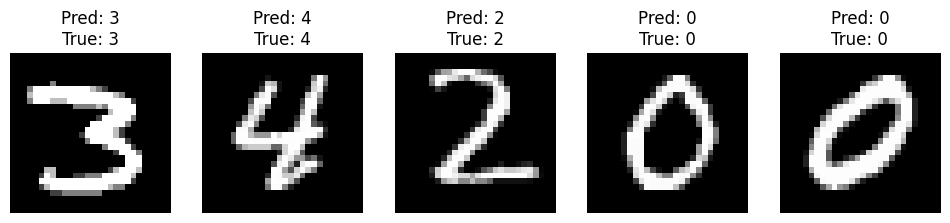

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    image = X_batch[i].cpu().squeeze()

    plt.imshow(image, cmap="gray")
    plt.axis("off")

    pred = y_pred[i].item()
    true = y_batch[i].item()

    plt.title(f"Pred: {pred}\nTrue: {true}")

plt.show()

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [17]:
all_preds = []
all_labels = []

model.eval()

with torch.inference_mode():
    for X, y in test_dataloader:
        X = X.to(device)
        y = y.to(device)

        y_logits = model(X)
        y_pred = torch.argmax(y_logits, dim=1)

        all_preds.append(y_pred.cpu())
        all_labels.append(y.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

print(all_preds.shape)
print(all_labels.shape)

torch.Size([10000])
torch.Size([10000])


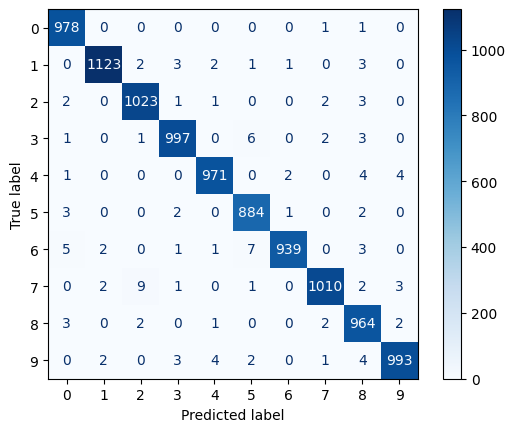

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels.numpy(),
    all_preds.numpy()
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")
plt.show()

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [23]:
rand_tensor = torch.rand(1, 3, 64, 64)

conv = torch.nn.Conv2d(
    in_channels=3,
    out_channels=8,
    kernel_size=3,
    stride=1,
    padding=0
)

y = conv(rand_tensor)

print(y.shape)

torch.Size([1, 8, 62, 62])


## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?